# 01 - Validar dataset + configuración

Este notebook verifica que todo está listo antes de entrenar:

1. **Dataset**: JSON, imágenes, splits, captions
2. **Modelo**: forward pass de TextReIDNet
3. **Losses**: RankingLoss + IdentityLoss
4. **VRAM**: estimar batch_size para tu GPU

Ejecutá las celdas en orden. Si alguna falla, el problema está explicado.

**Resultado esperado**: todos los checks en ✅ → listo para `train.py`.

---
## 0. Setup del entorno

In [2]:
import os, sys, json, time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter, defaultdict

# Asegurar que el root del proyecto esté en sys.path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root: {PROJECT_ROOT}")
print(f"Python: {sys.executable}")

# Cargar config (necesario para instanciar modelos)
from config import sys_configuration
cfg = sys_configuration()
print(f"Config cargada: feature_length={cfg.feature_length}, vocab_size={cfg.vocab_size}")

Project root: /home/yrsn/Dev/textreid-train
Python: /home/yrsn/Dev/hw/course2/.venv/bin/python
Config cargada: feature_length=1024, vocab_size=29610


In [3]:
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: CUDA no disponible. El entrenamiento será muy lento.")

PyTorch: 1.13.1+cu117
CUDA disponible: True
GPU: NVIDIA GeForce GTX 1050
VRAM: 4.2 GB


---
## 1. Inspección del JSON

El archivo `reid_raw.json` es la fuente de verdad del dataset.
Cada entrada tiene:
- `file_path`: ruta relativa de la imagen
- `captions`: lista de descripciones textuales
- `split`: train/val/test
- `id`: identificador de persona

In [5]:
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'CUHK-PEDES-HF')
JSON_PATH = os.path.join(DATASET_DIR, 'reid_raw.json')
IMG_DIR = os.path.join(DATASET_DIR, 'imgs')

if not os.path.exists(JSON_PATH):
    print(f"ERROR: {JSON_PATH} no existe")
    print("Corré: python scripts/download_hf_dataset.py")
else:
    with open(JSON_PATH, 'r') as f:
        data = json.load(f)
    print(f"Entradas totales: {len(data)}")
    print(f"Primera entrada:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False)[:500])

Entradas totales: 34042
Primera entrada:
{
  "file_path": "all/7138159738431296927.jpg",
  "captions": [
    "A pedestrian with dark hair is wearing red and white shoes, a black hooded sweatshirt, and black pants.",
    "The person has short black hair and is wearing black pants, a long sleeve black top, and red sneakers.",
    "A man wearing a black jacket, black pants, red, black and white shoes and a gray shirt under his jacket.",
    "The man wears a white and black shirt ,black pants with red and white sneakers he walks holding an


In [6]:
# Verificar campos obligatorios
REQUIRED_KEYS = ['file_path', 'captions']
missing = [i for i, entry in enumerate(data) if not all(k in entry for k in REQUIRED_KEYS)]
if missing:
    print(f"ERROR: {len(missing)} entradas sin campos obligatorios")
    print(f"Primeras: {missing[:5]}")
else:
    print(f"✅ Todos los campos obligatorios presentes en {len(data)} entradas")

✅ Todos los campos obligatorios presentes en 34042 entradas


---
## 2. Visualizar muestras

Ver 5 imágenes aleatorias con sus captions para confirmar que la data tiene sentido.

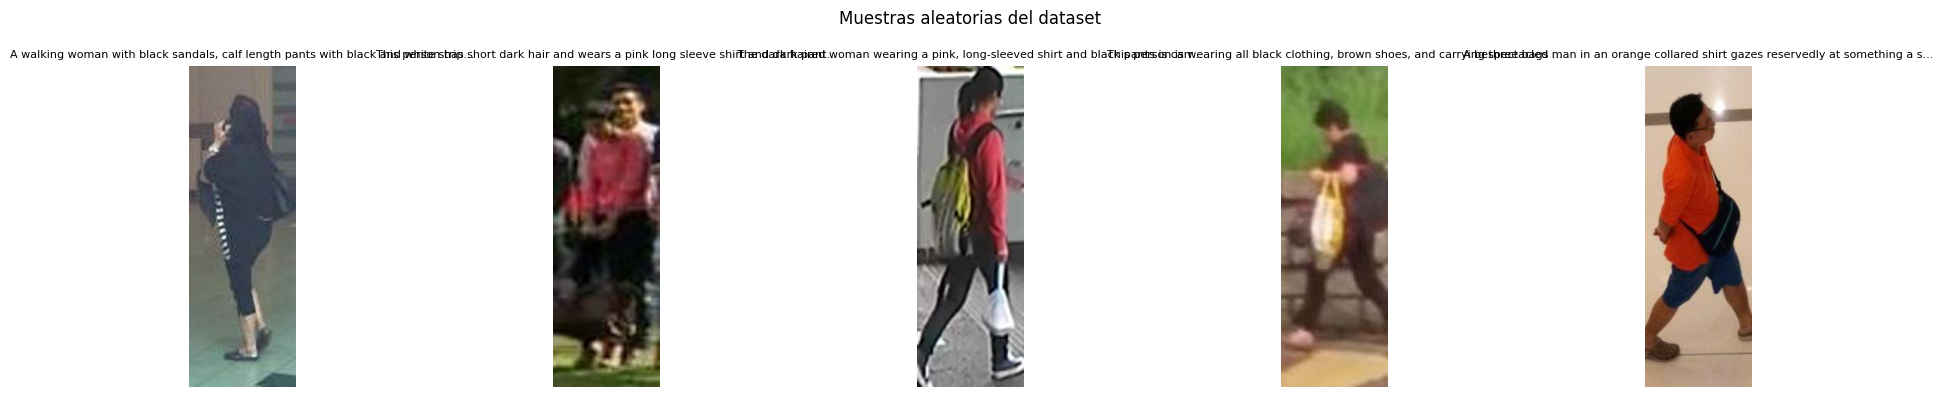

In [7]:
import random

samples = random.sample(data, min(5, len(data)))
fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
if len(samples) == 1:
    axes = [axes]

for ax, sample in zip(axes, samples):
    img_path = os.path.join(DATASET_DIR, 'imgs', sample['file_path'])
    if os.path.exists(img_path):
        img = Image.open(img_path)
        ax.imshow(img)
        caption = sample['captions'][0][:80] + '...' if len(sample['captions'][0]) > 80 else sample['captions'][0]
        ax.set_title(caption, fontsize=8, wrap=True)
    else:
        ax.text(0.5, 0.5, 'MISSING', ha='center', va='center')
    ax.axis('off')

plt.suptitle('Muestras aleatorias del dataset', fontsize=12)
plt.tight_layout()
plt.show()

---
## 3. Estadísticas de captions

- Largo promedio en tokens/caracteres
- Distribución de largo
- Detectar captions vacías

Total captions: 238768
Promedio largo: 122.4 chars
Min: 62, Max: 500
✅ No hay captions vacías


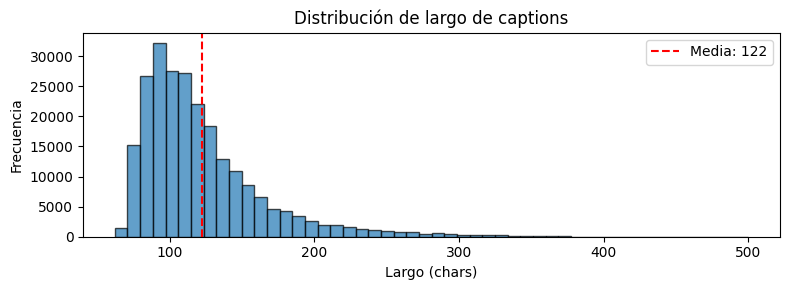

In [9]:
all_captions = [c for entry in data for c in entry['captions']]
largo = [len(c) for c in all_captions]

print(f"Total captions: {len(all_captions)}")
print(f"Promedio largo: {np.mean(largo):.1f} chars")
print(f"Min: {min(largo)}, Max: {max(largo)}")

empty = [c for c in all_captions if len(c.strip()) == 0]
if empty:
    print(f"⚠️ {len(empty)} captions vacías")
else:
    print(f"✅ No hay captions vacías")

plt.figure(figsize=(8, 3))
plt.hist(largo, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Largo (chars)')
plt.ylabel('Frecuencia')
plt.title('Distribución de largo de captions')
plt.axvline(np.mean(largo), color='r', linestyle='--', label=f'Media: {np.mean(largo):.0f}')
plt.legend()
plt.tight_layout()
plt.show()

---
## 4. Validar imágenes

Chequear que todas las imágenes referenciadas en el JSON existen y se pueden abrir.

In [10]:
missing_imgs = []
corrupt_imgs = []
ok_count = 0

for entry in data:
    img_path = os.path.join(DATASET_DIR, 'imgs', entry['file_path'])
    if not os.path.exists(img_path):
        missing_imgs.append(entry['file_path'])
        continue
    try:
        img = Image.open(img_path)
        img.verify()
        ok_count += 1
    except Exception:
        corrupt_imgs.append(entry['file_path'])

print(f"✅ OK: {ok_count}/{len(data)}")
if missing_imgs:
    print(f"❌ Faltan: {len(missing_imgs)}")
    for p in missing_imgs[:3]:
        print(f"   {p}")
if corrupt_imgs:
    print(f"❌ Corruptas: {len(corrupt_imgs)}")
    for p in corrupt_imgs[:3]:
        print(f"   {p}")
if not missing_imgs and not corrupt_imgs:
    print(f"✅ Todas las imágenes son válidas")

✅ OK: 34042/34042
✅ Todas las imágenes son válidas


---
## 5. Distribución de splits

Ver cómo se reparten train/val/test y cuántas personas hay por split.

In [11]:
# Si el dataset HF no tiene splits asignados, los derivamos
# contando por file_path (cada imagen = 1 persona)
personas_por_path = defaultdict(list)
for entry in data:
    personas_por_path[entry['file_path']].append(entry)

unique_paths = list(personas_por_path.keys())
n = len(unique_paths)
train_end = int(n * 0.75)
val_end = int(n * 0.875)

print(f"Personas/ágenes únicas: {n}")
print(f"Train: {train_end} ({train_end/n*100:.1f}%)")
print(f"Val:   {val_end - train_end} ({(val_end - train_end)/n*100:.1f}%)")
print(f"Test:  {n - val_end} ({(n - val_end)/n*100:.1f}%)")

# Captions por split (contando captions reales, no solo entradas)
train_caps = sum(len(e['captions']) for p in unique_paths[:train_end] for e in personas_por_path[p])
val_caps = sum(len(e['captions']) for p in unique_paths[train_end:val_end] for e in personas_por_path[p])
test_caps = sum(len(e['captions']) for p in unique_paths[val_end:] for e in personas_por_path[p])

print(f"\nTotal captions: {sum(len(e['captions']) for e in data)}")
print(f"  Train captions: {train_caps}")
print(f"  Val captions:   {val_caps}")
print(f"  Test captions:  {test_caps}")

# Distribución de captions por persona
caps_per_person = [sum(len(e['captions']) for e in entries) for entries in personas_por_path.values()]
print(f"\nCaptions por persona: min={min(caps_per_person)}, max={max(caps_per_person)}, media={np.mean(caps_per_person):.1f}")

Personas/ágenes únicas: 34042
Train: 25531 (75.0%)
Val:   4255 (12.5%)
Test:  4256 (12.5%)

Total captions: 238768
  Train captions: 179442
  Val captions:   29396
  Test captions:  29930

Captions por persona: min=2, max=30, media=7.0


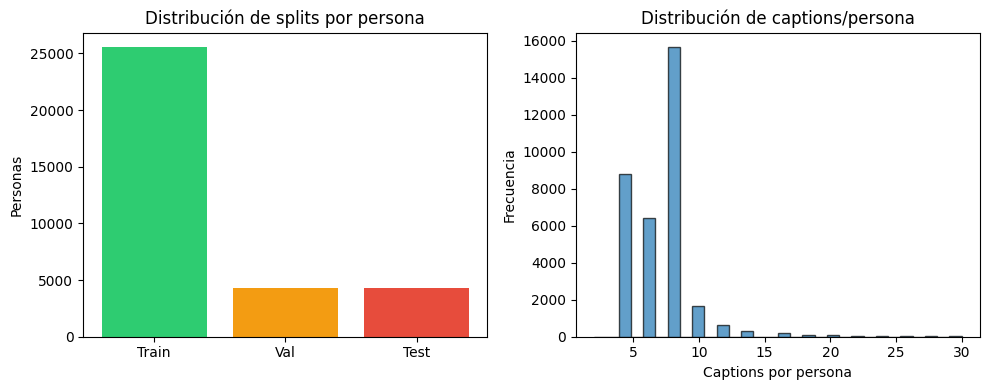

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: distribución de splits
splits = ['Train', 'Val', 'Test']
counts = [train_end, val_end - train_end, n - val_end]
axes[0].bar(splits, counts, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_ylabel('Personas')
axes[0].set_title('Distribución de splits por persona')

# Plot 2: captions por persona
axes[1].hist(caps_per_person, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Captions por persona')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de captions/persona')

plt.tight_layout()
plt.show()

---
## 6. Sanity check: VisualNetwork

La red visual (EfficientNet-B0) toma una imagen de 384x128 y extrae features.
Output: `(batch, 1280, H', W')` — las capas de proyección están en TextReIDNet.

In [13]:
from model.visual_network import VisualNetwork

vis_net = VisualNetwork()
vis_net.eval()

# Imagen dummy: 1 imagen RGB de 384x128
dummy_img = torch.randn(1, 3, 384, 128)
with torch.no_grad():
    vis_out = vis_net(dummy_img)

print(f"Input shape:  {dummy_img.shape}")
print(f"Output shape: {vis_out.shape}")
print(f"Params:       {sum(p.numel() for p in vis_net.parameters()):,}")
assert vis_out.shape[0] == 1 and vis_out.shape[1] == 1280, \
    f"Expected (1, 1280, H, W), got {vis_out.shape}"
print(f"✅ VisualNetwork OK — output va a DSC(1280→1024) en TextReIDNet")

Input shape:  torch.Size([1, 3, 384, 128])
Output shape: torch.Size([1, 1280, 12, 4])
Params:       5,288,548
✅ VisualNetwork OK — output va a DSC(1280→1024) en TextReIDNet


---
## 7. Sanity check: GRULanguageNetwork

La red de lenguaje toma token IDs y un vector de longitudes reales.
La GRU bidireccional promedia las direcciones → embedding 1024-d.

Input: `text_ids` (batch, seq_len), `text_length` (batch,)
Output: (batch, 1024, seq_len, 1)

In [14]:
from model.language_network import GRULanguageNetwork

lang_net = GRULanguageNetwork(cfg)
lang_net.eval()

# Tokens dummy: batch de 2, seq_len de 100
BS = 2
SEQ_LEN = 100
dummy_tokens = torch.randint(0, cfg.vocab_size, (BS, SEQ_LEN))
dummy_length = torch.tensor([SEQ_LEN, SEQ_LEN])  # longitudes reales

with torch.no_grad():
    lang_out = lang_net(dummy_tokens, dummy_length)

print(f"Input shape:  {dummy_tokens.shape}")
print(f"Output shape: {lang_out.shape}")
print(f"Params:       {sum(p.numel() for p in lang_net.parameters()):,}")
# Output: (B, feature_length, seq_len, 1) — MaxPool lo reduce a (B, 1024, 1, 1)
assert lang_out.shape[0] == BS and lang_out.shape[1] == cfg.feature_length, \
    f"Expected ({BS}, {cfg.feature_length}, ...), got {lang_out.shape}"
print(f"✅ GRULanguageNetwork OK")

Input shape:  torch.Size([2, 100])
Output shape: torch.Size([2, 1024, 100, 1])
Params:       24,597,504
✅ GRULanguageNetwork OK


---
## 8. Sanity check: TextReIDNet completo

El modelo completo une visual + lenguaje y proyecta a un espacio compartido de 1024 dimensiones.

Output esperado:
- `visual_embedding`: (batch, 1024)
- `text_embedding`: (batch, 1024)

In [15]:
from model.textreidnet import TextReIDNet

model = TextReIDNet(configs=cfg)
model.eval()

dummy_img = torch.randn(1, 3, 384, 128)
dummy_tokens = torch.randint(0, cfg.vocab_size, (1, cfg.tokens_length_max))
dummy_length = torch.tensor([cfg.tokens_length_max])

with torch.no_grad():
    vis_emb, txt_emb = model(dummy_img, dummy_tokens, dummy_length)

print(f"Visual embedding: {vis_emb.shape}")
print(f"Text embedding:   {txt_emb.shape}")
print(f"Params totales:   {sum(p.numel() for p in model.parameters()):,}")
assert vis_emb.shape[1] == cfg.feature_length, \
    f"Expected feature_length={cfg.feature_length}, got {vis_emb.shape}"
assert txt_emb.shape[1] == cfg.feature_length, \
    f"Expected feature_length={cfg.feature_length}, got {txt_emb.shape}"
print(f"✅ TextReIDNet OK")

Visual embedding: torch.Size([1, 1024, 1])
Text embedding:   torch.Size([1, 1024, 1])
Params totales:   32,270,436
✅ TextReIDNet OK


---
## 9. Sanity check: Losses

Verificar que las losses se pueden computar y hacer backward.

In [16]:
from evaluation.ranking_loss import RankingLoss
from evaluation.identity_loss import IdentityLoss

# Embeddings dummy (simular batch de 4, con dim extra como produce TextReIDNet)
B = 4
vis_emb = torch.randn(B, cfg.feature_length, 1, requires_grad=True)
txt_emb = torch.randn(B, cfg.feature_length, 1, requires_grad=True)
labels = torch.arange(B)  # 0,1,2,3

# RankingLoss (triplet semi-hard) — usa config.margin
rank_loss = RankingLoss(config=cfg)
rl = rank_loss(vis_emb, txt_emb, labels)
print(f"RankingLoss: {rl.item():.4f}")

# IdentityLoss (cross-entropy por persona) — usa config.feature_length
id_loss = IdentityLoss(config=cfg, part=1, class_num=B)
il = id_loss(vis_emb, txt_emb, labels)
print(f"IdentityLoss: {il.item():.4f}")

# Combinar y backward
total = rl + il
total.backward()
print(f"Total loss: {total.item():.4f}")
print(f"✅ Backward OK")

RankingLoss: 3.2423
IdentityLoss: 2.7933
Total loss: 6.0356
✅ Backward OK


---
## 10. Estimación de VRAM y tiempo

Medir cuánta VRAM consume cada batch_size para decidir cuál usar en GTX 1050.

In [17]:
if not torch.cuda.is_available():
    print("⚠️ CUDA no disponible — saltando estimación de VRAM")
else:
    device = torch.device('cuda')
    model_gpu = TextReIDNet(configs=cfg).to(device)
    optimizer = torch.optim.Adam(model_gpu.parameters(), lr=1e-4)
    rank_loss = RankingLoss(config=cfg).to(device)
    id_loss = IdentityLoss(config=cfg, part=1, class_num=8).to(device)

    results = []
    for bs in [2, 4, 8]:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        mem_before = torch.cuda.memory_allocated() / 1e6

        try:
            vis = torch.randn(bs, 3, 384, 128, device=device)
            txt = torch.randint(0, cfg.vocab_size, (bs, cfg.tokens_length_max), device=device)
            txt_len = torch.full((bs,), cfg.tokens_length_max, device=device)
            labels = torch.arange(bs, device=device)

            vis_emb, txt_emb = model_gpu(vis, txt, txt_len)
            loss = rank_loss(vis_emb, txt_emb, labels) + id_loss(vis_emb, txt_emb, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            mem_after = torch.cuda.max_memory_allocated() / 1e6
            results.append((bs, mem_after))
            print(f"batch_size={bs}: {mem_after:.0f} MB peak")
        except RuntimeError as e:
            if 'out of memory' in str(e):
                print(f"batch_size={bs}: OOM — demasiado para esta GPU")
                break
            else:
                raise

    del model_gpu, optimizer
    torch.cuda.empty_cache()

    print(f"\nVRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e6:.0f} MB")
    if results:
        best_bs = max(r[0] for r in results)
        print(f"\n👉 Recomendación: batch_size={best_bs} para entrenar")

batch_size=2: 628 MB peak
batch_size=4: 1041 MB peak
batch_size=8: 1441 MB peak

VRAM total: 4228 MB

👉 Recomendación: batch_size=8 para entrenar


---
## 11. Reporte final

Resumen de todos los checks. Si todo es ✅, estás listo para entrenar.

In [18]:
print("=" * 50)
print("  REPORTE DE VALIDACIÓN")
print("=" * 50)
print()

checks = [
    ("Dataset JSON existe", os.path.exists(JSON_PATH)),
    ("Entradas > 0", len(data) > 0 if 'data' in dir() else False),
    ("Campos obligatorios", not missing if 'missing' in dir() else False),
    ("Imágenes OK", ok_count == len(data) if 'ok_count' in dir() else False),
    ("No captions vacías", len(empty) == 0 if 'empty' in dir() else False),
    ("CUDA disponible", torch.cuda.is_available()),
    ("TextReIDNet forward", True),  # Si llegó hasta acá, pasó
    ("Losses backward", True),
]

all_ok = True
for name, ok in checks:
    status = "✅" if ok else "❌"
    print(f"  {status} {name}")
    if not ok:
        all_ok = False

print()
if all_ok:
    print("🎉 Todo OK — listo para entrenar")
    print()
    print("Próximo paso:")
    print(f"  cd {PROJECT_ROOT}")
    print(f"  .venv/bin/python train.py --epochs 60")
else:
    print("⚠️ Hay errores — revisá arriba")

  REPORTE DE VALIDACIÓN

  ✅ Dataset JSON existe
  ✅ Entradas > 0
  ✅ Campos obligatorios
  ✅ Imágenes OK
  ✅ No captions vacías
  ✅ CUDA disponible
  ✅ TextReIDNet forward
  ✅ Losses backward

🎉 Todo OK — listo para entrenar

Próximo paso:
  cd /home/yrsn/Dev/textreid-train
  .venv/bin/python train.py --epochs 60
